#### Perform a Classification Evaluation Metrics and check whether the person is sufferig from diabetes or not


##### Step 1: Import all the necessary libraries

In [1047]:
import  numpy   as  np
import  pandas  as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection import  train_test_split, GridSearchCV
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.linear_model    import  LinearRegression
from    sklearn.pipeline        import  Pipeline
from    sklearn.metrics         import  accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score, roc_curve

#### OBSERVATIONS:

1.  Pipeline ------------->   It avoids the data leakage

2.  GridSearchCV --------->   It performs the hyperparameter tuning

3.  StandardScaler ------->   It performs the feature scaling on the inputs

#### Step 2: Load the dataset

In [1048]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

#### define the column names
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


df = pd.read_csv(url, names = columns)

print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

#### OBSERVATIONS:

1.  The above dataset explains about the diabetic situation about each and every patient who are suffering from diabetes or not.

2.  The input or the independent features are from Pregnancies ...... Age

3.  The dependent feature is the Outcome.

#### Step 3: Perform the Data Exploration

In [1049]:
#### Get the total length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 768


In [1050]:
#### Get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (768, 9)


In [1051]:
#### Get the top five reocrds of the dataset

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [1052]:
#### Get the last five reocrds of the dataset

print(df.tail())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
763                     0.171   63        0  
764                     0.340   27        0  
765                     0.245   30        0  
766                     0.349   47        1  
767                     0.315   23        0  


In [1053]:
#### Get the columns used in the dataset

df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [1054]:
#### get the information about the columns used in the dataste

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [1055]:
#### Get the descriotive statistical summary about the dataset

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### OBSERVATIONS:

1.  It explains about the statistical summary about each column used in the dataset.

In [1056]:
#### Get the correlation between all the columns used in the dataset

df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

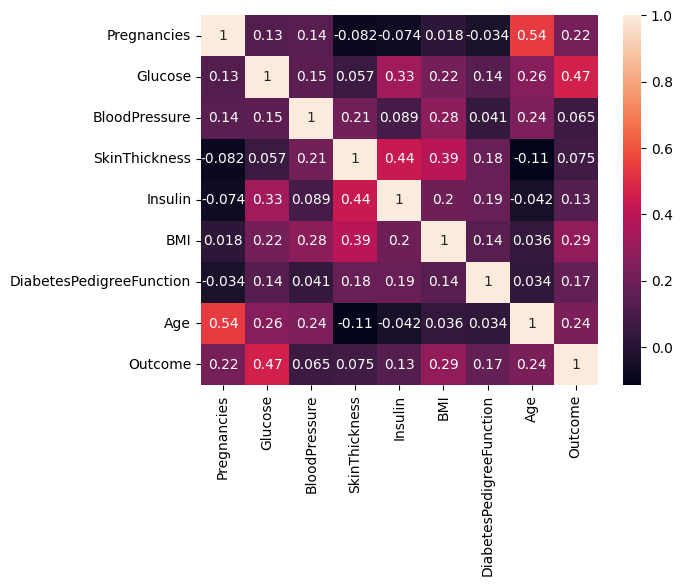

In [1057]:
#### Get the graphical visualization for the above columns used in the dataset

sns.heatmap(df.corr(), annot=True)

#### OBSERVATIONS:

1.  The above graph explains about the correlation between all the columns used in the dataset.

2.  The high correlation is marked  as red in color.

3.  The low  correlation is marked as dark blue in color.

#### Step 4: Perform Data Cleaning

In [1058]:
### To check for the NULL records used in the dataset

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records used in the dataset.

In [1059]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


#### OBSERVATIONS:

1. There are no duplicate records used in the dataset.

#### Step 5: Divide the dataset into independent and dependent variables

In [1060]:
##### Independent variables

X = df.drop(columns = 'Outcome', axis=1)

print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [1061]:
#### Dependent variables

Y = df[['Outcome']]

print(Y)

     Outcome
0          1
1          0
2          1
3          0
4          1
..       ...
763        0
764        0
765        0
766        1
767        0

[768 rows x 1 columns]


#### OBSERVATIONS:

1.  The dataset is divided into the independent and dependent variables.

2.  The independent variable comprises of Pregnancies .......Age

3.  The dependent  variable is the Outcome which tells whether the person is having diabetes or not.

#### Step 6: Divide the independent and dependent variables into the training and testing data

In [1062]:
from   sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [1063]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90,62,12,43,27.2,0.580,24
711,5,126,78,27,22,29.6,0.439,40
373,2,105,58,40,94,34.9,0.225,25
46,1,146,56,0,0,29.7,0.564,29
682,0,95,64,39,105,44.6,0.366,22
...,...,...,...,...,...,...,...,...
451,2,134,70,0,0,28.9,0.542,23
113,4,76,62,0,0,34.0,0.391,25
556,1,97,70,40,0,38.1,0.218,30
667,10,111,70,27,0,27.5,0.141,40


In [1064]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159,64,0,0,27.4,0.294,40
672,10,68,106,23,49,35.5,0.285,47
700,2,122,76,27,200,35.9,0.483,26
630,7,114,64,0,0,27.4,0.732,34
81,2,74,0,0,0,0.0,0.102,22
...,...,...,...,...,...,...,...,...
32,3,88,58,11,54,24.8,0.267,22
637,2,94,76,18,66,31.6,0.649,23
593,2,82,52,22,115,28.5,1.699,25
425,4,184,78,39,277,37.0,0.264,31


In [1065]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (614, 8)
Shape of the input testing  data is: (154, 8)


In [1066]:
Y_train

,Outcome
353,0
711,0
373,0
46,0
682,0
...,...
451,1
113,0
556,0
667,1


In [1067]:
Y_test

,Outcome
44,0
672,0
700,0
630,1
81,0
...,...
32,0
637,0
593,0
425,1


In [1068]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (614, 1)
Shape of the output testing  data is: (154, 1)


#### OBSERVATIONS:

1.  The dataset is divided into the training and testing data.

2.  The training contains 80 % of the data and the testing data contains 20 % of the data.

#### Step 7: Perform the Pipeline and HyperParameter Tuning

In [1069]:
#### Create the object of Pipeline

pipeline = Pipeline([
    ("sc"    ,        StandardScaler())                           ,
    ("log"   ,        LogisticRegression(max_iter=1000))
])


#### Define the list of Hyper Parameters used for tuning the model

param_grid = {
    'log__C'       :      [0.01 , 0.1, 1, 10]                        ,
    'log__penalty' :      ['l2']                                     ,
    'log__solver'   :      ['lbfgs']   
}


grid = GridSearchCV(
    pipeline                                                          ,
    param_grid                                                        ,
    cv            =            5                                      ,
    scoring       =        'accuracy'                                 ,
    n_jobs        =            -1 
)

In [1070]:
#### using the object of gridsearchcv,  train the model
grid.fit(X_train, Y_train)

d:\HDD DATA\New folder d\Generative_AI\1-Python\Machine_Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\HDD DATA\New folder d\Generative_AI\1-Python\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'log__C': [0.01, 0.1, ...], 'log__penalty': ['l2'], 'log__solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [1071]:
#### Get the best parameters from the model

print("Best parameters for the model is:", grid.best_params_)

Best parameters for the model is: {'log__C': 1, 'log__penalty': 'l2', 'log__solver': 'lbfgs'}


In [1072]:
#### Get the best model

best_model = grid.best_estimator_
print("Best Estimator for the model is:", best_model)

Best Estimator for the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('log', LogisticRegression(C=1, max_iter=1000, penalty='l2'))])


#### OBSERVATIONS:

1. The best parameter for the model is 

      C    ------------->      1

      penalty ---------->     l2

      solver ----------->    lbfgs


2.  The best estimator for the model is


     Standard Scaler


     Logistic Regression

#### Step 8: Predict the Model

In [1073]:
Y_pred = best_model.predict(X_test)

In [1074]:
Y_pred

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0])

In [1075]:
### Get the probability for each class

Y_pred_proba = best_model.predict_proba(X_test)[:,1]

In [1076]:
Y_pred_proba

array([0.61667353, 0.11278116, 0.27253958, 0.28668164, 0.00448143,
       0.18904882, 0.46842913, 0.91697653, 0.10324589, 0.78113127,
       0.29613608, 0.63597286, 0.12786193, 0.09909978, 0.30866116,
       0.3507186 , 0.70392033, 0.09531777, 0.78252641, 0.23536029,
       0.16664796, 0.65671549, 0.18393873, 0.92643551, 0.52785293,
       0.01880984, 0.5887942 , 0.05766689, 0.33522309, 0.04281283,
       0.050227  , 0.05265587, 0.4613617 , 0.55726873, 0.8518256 ,
       0.13560198, 0.32840637, 0.0754743 , 0.74097894, 0.58611971,
       0.30527919, 0.10551335, 0.09793284, 0.29739564, 0.15755713,
       0.41726768, 0.17432501, 0.1229056 , 0.58461656, 0.52171584,
       0.65229788, 0.81955981, 0.3749456 , 0.07716855, 0.5118915 ,
       0.34345968, 0.7746283 , 0.23958681, 0.74641966, 0.14703567,
       0.76887073, 0.21935336, 0.00657952, 0.86809851, 0.0437365 ,
       0.15206912, 0.93705313, 0.02222134, 0.277012  , 0.6432003 ,
       0.19562609, 0.09992288, 0.32767586, 0.47411374, 0.04322

#### OBSERVATIONS:

1. The predicted output is obtained for the test class.

2. The probabilities for each output class is also obtained.

#### Step 9: Evaluate the Classification Metrics

In [1077]:
from    sklearn.metrics         import  accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score, roc_auc_score

In [1078]:
print("==============================Accuracy Score===========================================")

ac = (accuracy_score(Y_test, Y_pred))*100.0

print("Accuracy of the model is:", (ac))

==============================Accuracy Score===========================================
Accuracy of the model is: 71.42857142857143


#### OBSERVATIONS:

1.  The accuracy  of the model is 71.42 which is fine. So the model is working good.

In [1079]:
print("==============================Confusion Matrix===========================================")

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion Matrix of the model is:", (cm))

==============================Confusion Matrix===========================================
Confusion Matrix of the model is: [[82 18]
 [26 28]]


In [1080]:
print("============================== Classification Report ===========================================")

cr = classification_report(Y_test, Y_pred)

print("Classification Report of the model is:", (cr))

============================== Classification Report ===========================================
Classification Report of the model is:               precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [1081]:
print("==============================Precision Score===========================================")

pr = precision_score(Y_test, Y_pred)

print("Precision Score of the model is:", (pr))

==============================Precision Score===========================================
Precision Score of the model is: 0.6086956521739131


In [1082]:
print("==============================Recall Score===========================================")

re = recall_score(Y_test, Y_pred)

print("Recall Score of the model is:", (re))

==============================Recall Score===========================================
Recall Score of the model is: 0.5185185185185185


In [1083]:
print("==============================F1 Score===========================================")

f1 = f1_score(Y_test, Y_pred)

print("F1 Score of the model is:", (f1))

==============================F1 Score===========================================
F1 Score of the model is: 0.56


In [1084]:
print("==============================ROC AUC Score===========================================")

roc = roc_auc_score(Y_test, Y_pred)

print("ROC Score of the model is:", (roc))

==============================ROC AUC Score===========================================
ROC Score of the model is: 0.6692592592592593


In [1085]:

print("Accuracy:", ac)
print("Precision:", pr)
print("Recall:", re)
print("F1 Score:", f1)
print("ROC-AUC:", roc)

Accuracy: 71.42857142857143
Precision: 0.6086956521739131
Recall: 0.5185185185185185
F1 Score: 0.56
ROC-AUC: 0.6692592592592593


#### Step 10: Perform the Graphical Visualization for the ROC Curve

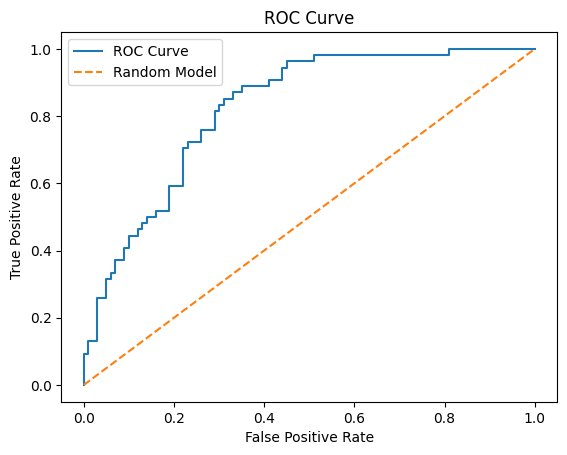

In [1086]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### OBSERVATIONS:

1. The above graph represents the graphical visualization between the False Positive Rate vs the True Positive Rate.